# Módulo 1 — Fundamentos de Text Mining
## Exercício Prático: Analisando Reviews da Olist com BoW e TF-IDF

**Prof. Gabriel Antunes | Data Science Analytics**

---

### Objetivo
Ao final deste notebook você terá:
- Explorado o dataset Olist de reviews (100k registros reais)
- Aplicado o pipeline completo de pré-processamento de texto em português
- Construído uma matriz Bag of Words e calculado pesos TF-IDF
- Treinado e avaliado um classificador de sentimento baseline

### Dataset
- **Arquivo:** `olist_order_reviews_dataset.csv`
- **Colunas principais:** `review_score` (1–5), `review_comment_message` (texto livre)
- **100.000 reviews**, dos quais ~41.728 contêm texto



In [ ]:
# ── Instalação de dependências ──────────────────────────────
# Execute esta célula apenas uma vez
!pip install nltk pandas scikit-learn matplotlib seaborn wordcloud --quiet

In [25]:
# ── Imports ─────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import RSLPStemmer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from wordcloud import WordCloud

# Download recursos NLTK para português
for resource in ['stopwords', 'punkt', 'punkt_tab', 'rslp']:
    nltk.download(resource, quiet=True)

# Configuração de visualização
plt.style.use('seaborn-v0_8-whitegrid')
CORES = {'1': '#E8553E', '2': '#F59E0B', '3': '#6B7280', '4': '#0A8A7A', '5': '#1B2B5E'}
print('✅ Dependências carregadas com sucesso!')

✅ Dependências carregadas com sucesso!


---

## Aplicação Pratica 1 — Exploração do Dataset


> **Objetivo:** entender a estrutura dos dados, distribuição de notas e tamanho dos textos antes de qualquer processamento.

In [26]:
# ── Carregamento dos dados ───────────────────────────────────

CAMINHO = 'olist_order_reviews_dataset.csv'

df = pd.read_csv(CAMINHO)
print(f'Shape: {df.shape}')
df.head()

Shape: (100000, 7)


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [27]:

# a) Reviews com texto
df_texto = df[df['review_comment_message'].notna() & (df['review_comment_message'].str.strip() != '')].copy()
print(f"Reviews com texto: {len(df_texto):,} ({len(df_texto)/len(df)*100:.1f}% do total)")

# b) Distribuição de notas
print("\nDistribuição de notas:")
dist = df['review_score'].value_counts().sort_index()
for nota, count in dist.items():
    bar = '█' * int(count / 1000)
    print(f"  {nota}★ {bar} {count:>6,} ({count/len(df)*100:.1f}%)")

# c) Comprimento médio por nota
df_texto['n_chars'] = df_texto['review_comment_message'].str.len()
print("\nComprimento médio do texto por nota:")
print(df_texto.groupby('review_score')['n_chars'].mean().round(1).to_string())

Reviews com texto: 41,726 (41.7% do total)

Distribuição de notas:
  1★ ███████████ 11,858 (11.9%)
  2★ ███  3,235 (3.2%)
  3★ ████████  8,287 (8.3%)
  4★ ███████████████████ 19,200 (19.2%)
  5★ █████████████████████████████████████████████████████████ 57,420 (57.4%)

Comprimento médio do texto por nota:
review_score
1    102.1
2     98.0
3     85.1
4     62.4
5     52.1


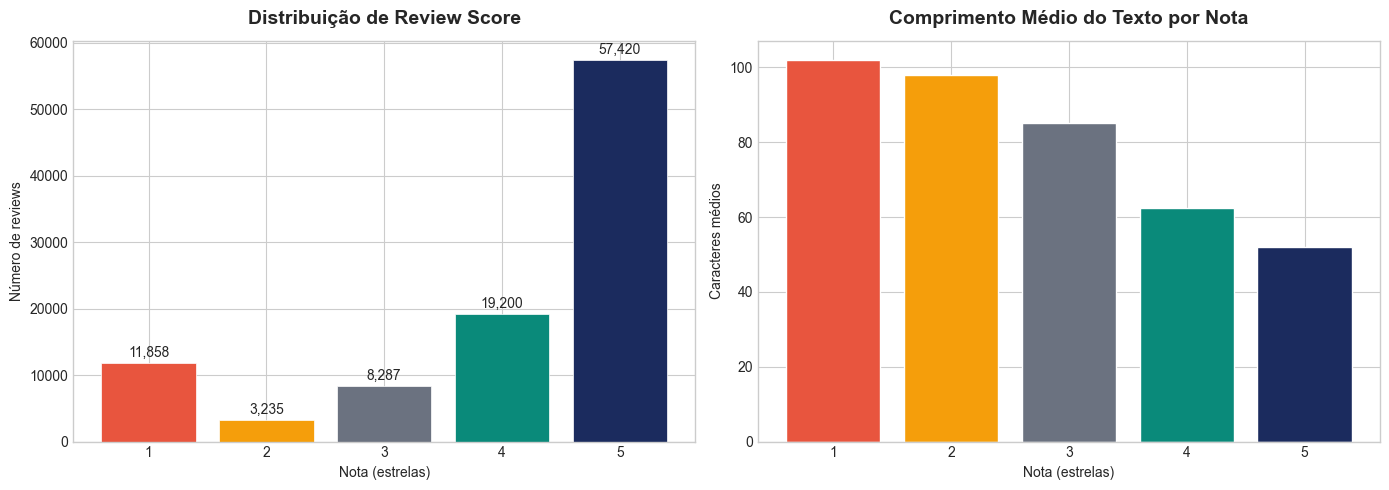

💡 Insight: reviews negativos (1★) tendem a ser mais longos — clientes insatisfeitos explicam mais!


In [28]:
# ── Visualização: Distribuição de notas ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Contagem de notas
notas = dist.index.astype(str)
cores = [CORES[n] for n in notas]
bars = axes[0].bar(notas, dist.values, color=cores, edgecolor='white', linewidth=0.5)
axes[0].set_title('Distribuição de Review Score', fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('Nota (estrelas)')
axes[0].set_ylabel('Número de reviews')
for bar, val in zip(bars, dist.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{val:,}', ha='center', va='bottom', fontsize=10)

# Gráfico 2: Comprimento do texto por nota
comp_by_nota = df_texto.groupby('review_score')['n_chars'].mean()
axes[1].bar(comp_by_nota.index.astype(str), comp_by_nota.values,
            color=[CORES[str(n)] for n in comp_by_nota.index], edgecolor='white')
axes[1].set_title('Comprimento Médio do Texto por Nota', fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel('Nota (estrelas)')
axes[1].set_ylabel('Caracteres médios')

plt.tight_layout()
plt.savefig('01_distribuicao_notas.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 Insight: reviews negativos (1★) tendem a ser mais longos — clientes insatisfeitos explicam mais!")

---
## Aplicação Pratica 1.1 — Bag of Words

> **Objetivo:** transformar os textos processados em uma matriz documento-termo e analisar as palavras mais discriminativas por nota.

In [29]:
# a) Construção da matriz BoW
vectorizer_bow = CountVectorizer(max_features=5000, min_df=3, ngram_range=(1,1))
X_bow = vectorizer_bow.fit_transform(df_texto['review_comment_message'])
vocab = vectorizer_bow.get_feature_names_out()

print(f"Shape da matriz BoW: {X_bow.shape}")
print(f"  {X_bow.shape[0]:,} documentos × {X_bow.shape[1]:,} tokens")
print(f"  Esparsidade: {(1 - X_bow.nnz / (X_bow.shape[0] * X_bow.shape[1]))*100:.1f}%")

# b) Top tokens do corpus
freqs = np.asarray(X_bow.sum(axis=0)).flatten()
top15_idx = freqs.argsort()[::-1][:15]
print("\nTop 15 tokens mais frequentes no corpus:")
for i, idx in enumerate(top15_idx, 1):
    print(f"  {i:2}. {vocab[idx]:<20} {freqs[idx]:>7,}")

# c) Top tokens por nota
df_bow = pd.DataFrame.sparse.from_spmatrix(X_bow, columns=vocab)
df_bow['review_score'] = df_texto['review_comment_message'].values

print("\nTop 10 tokens em reviews de 1★:")
top_1 = df_bow[df_bow['review_score']==1].drop('review_score',axis=1).sum().sort_values(ascending=False)[:10]
for token, freq in top_1.items():
    print(f"  {token:<20} {int(freq):>5,}")

print("\nTop 10 tokens em reviews de 5★:")
top_5 = df_bow[df_bow['review_score']==5].drop('review_score',axis=1).sum().sort_values(ascending=False)[:10]
for token, freq in top_5.items():
    print(f"  {token:<20} {int(freq):>5,}")

Shape da matriz BoW: (41726, 5000)
  41,726 documentos × 5,000 tokens
  Esparsidade: 99.8%

Top 15 tokens mais frequentes no corpus:
   1. produto               18,865
   2. de                    11,781
   3. do                    11,394
   4. não                   11,317
   5. que                    8,761
   6. prazo                  8,543
   7. muito                  8,048
   8. entrega                6,679
   9. com                    6,091
  10. antes                  5,655
  11. chegou                 5,643
  12. recebi                 5,463
  13. no                     5,355
  14. foi                    4,756
  15. bom                    4,637

Top 10 tokens em reviews de 1★:
  00                       0
  ou                       0
  ouve                     0
  outubro                  0
  outros                   0
  outro                    0
  outras                   0
  outra                    0
  ouro                     0
  otimos                   0

Top 10 tokens em r

---
## Aplicação Pratica 1.2 — Worldcloud

> **Objetivo:** transformar os textos processados em uma matriz documento-termo e analisar as palavras mais discriminativas por nota.

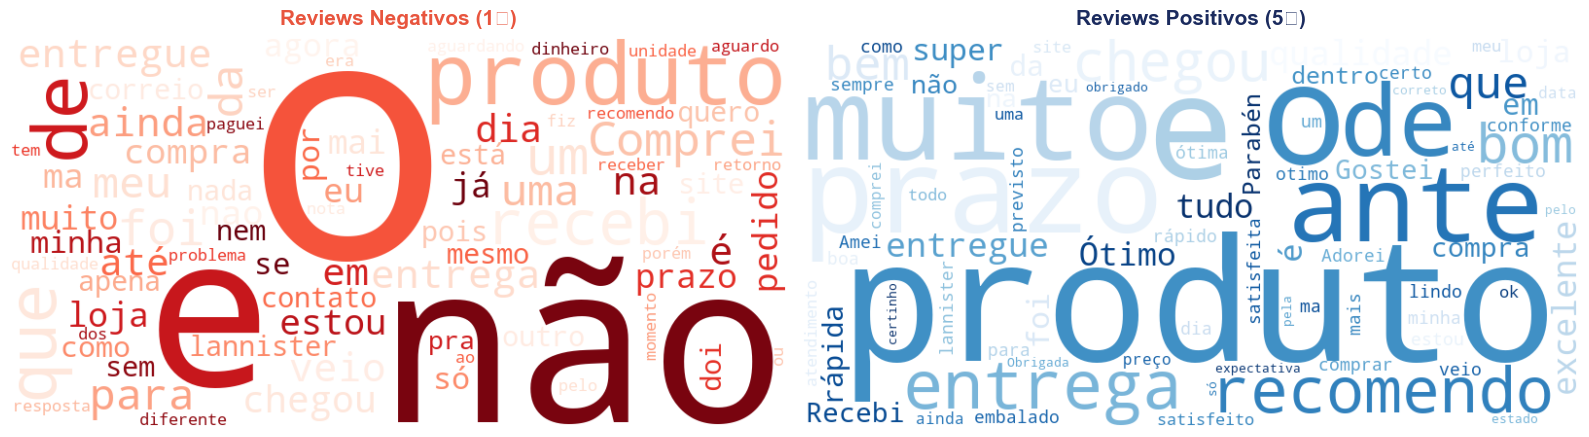

💡 Observe as diferenças: palavras como 'cheg', 'praz', 'recomend' dominam o 5★;
   já 'nao', 'produt', 'pag', 'entreg' aparecem mais no 1★.


In [30]:
# ── WordCloud: 1★ vs 5★ ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, nota, cor, titulo in [
    (axes[0], 1, '#E8553E', 'Reviews Negativos (1★)'),
    (axes[1], 5, '#1B2B5E', 'Reviews Positivos (5★)'),
]:  
    textos = ' '.join(df_texto[df_texto['review_score']==nota]['review_comment_message'])
    wc = WordCloud(width=800, height=400, background_color='white',
                   colormap='Reds' if nota==1 else 'Blues',
                   max_words=80, collocations=False).generate(textos)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(titulo, fontsize=15, fontweight='bold', color=cor, pad=10)

plt.tight_layout()
plt.savefig('02_wordcloud_bow.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Aplicação pratica 2 — Pré-processamento de Texto

> **Objetivo:** limpar e normalizar os reviews antes de vetorizá-los. Cada etapa elimina ruído que prejudicaria a qualidade das features.

In [ ]:
STOPWORDS_PT = set(stopwords.words('portuguese')) #MUITO IMPORTANTE PARA RETIRAR PALAVRAS MUITO COMUNS E COM POUCO SIGNIFICADO ESTATISTICO


In [31]:

stemmer = RSLPStemmer()

def preprocessar(texto):
    if not isinstance(texto, str) or texto.strip() == '':
        return ''
    # 1. Minúsculas
    texto = texto.lower()
    # 2. Remoção de ruído
    texto = re.sub(r'http\S+|www\S+', '', texto)   # URLs
    texto = re.sub(r'\S+@\S+', '', texto)           # emails
    texto = re.sub(r'\d+', '', texto)               # números
    texto = re.sub(r'[^\w\s]', ' ', texto)          # pontuação
    texto = re.sub(r'\s+', ' ', texto).strip()      # espaços extras
    # 3. Tokenização
    tokens = word_tokenize(texto, language='portuguese')
    # 4. Remove stopwords + tokens curtos
    tokens = [t for t in tokens if t not in STOPWORDS_PT and len(t) > 2]
    # 5. Stemming
    tokens = [stemmer.stem(t) for t in tokens]
    return ' '.join(tokens)

# Teste
exemplos = [
    "Recebi meu PRODUTO muito! Rápido, adorei totalmente :)",
    "Produto péssimo, demorou muito e veio quebrado. Nunca mais compro!",
    "Ótimo! Chegou antes do prazo estipulado."
]
for ex in exemplos:
    print(f"Original : {ex}")
    print(f"Processado: {preprocessar(ex)}")
    print()

Original : Recebi meu PRODUTO muito! Rápido, adorei totalmente :)
Processado: receb produt rápid ador total

Original : Produto péssimo, demorou muito e veio quebrado. Nunca mais compro!
Processado: produt péss demor vei quebr nunc compr

Original : Ótimo! Chegou antes do prazo estipulado.
Processado: ótim cheg ant praz estipul



In [32]:
# ── Aplicar pré-processamento ao dataset ──────────────────── PODE LEVAR uns minutos
print("Processando reviews... ")
df_texto['texto_proc'] = df_texto['review_comment_message'].apply(preprocessar)

# Remover textos vazios após processamento
df_clean = df_texto[df_texto['texto_proc'].str.strip() != ''].copy()
print(f"Reviews válidos após processamento: {len(df_clean):,}")
print("\nExemplo antes/depois:")
sample = df_clean.sample(3, random_state=42)[['review_score','review_comment_message','texto_proc']]
for _, row in sample.iterrows():
    print(f"  [{row['review_score']}★] Original : {str(row['review_comment_message'])[:80]}")
    print(f"       Processado: {row['texto_proc'][:80]}")
    print()

Processando reviews... 
Reviews válidos após processamento: 41,352

Exemplo antes/depois:
  [5★] Original : Ótima compra. Produto entregue no prazo.
Só fico muito injuriado com o imposto c
       Processado: ótim compr produt entreg praz fic injuri impost cobr govern

  [5★] Original : Recebi meu livro em perfeitas condições e no prazo. Recomento a loja.
       Processado: receb livr perfeit cond praz recoment loj

  [5★] Original : Excelente
       Processado: excel



---
## Aplicação pratica 2 — Pré-processamento de Texto — Bag of Words Corrigido

> **Objetivo:** transformar os textos processados em uma matriz documento-termo e analisar as palavras mais discriminativas por nota.

In [33]:
# a) Construção da matriz BoW
vectorizer_bow = CountVectorizer(max_features=5000, min_df=3, ngram_range=(1,1))
X_bow = vectorizer_bow.fit_transform(df_clean['texto_proc'])
vocab = vectorizer_bow.get_feature_names_out()

print(f"Shape da matriz BoW: {X_bow.shape}")
print(f"  {X_bow.shape[0]:,} documentos × {X_bow.shape[1]:,} tokens")
print(f"  Esparsidade: {(1 - X_bow.nnz / (X_bow.shape[0] * X_bow.shape[1]))*100:.1f}%")

# b) Top tokens do corpus
freqs = np.asarray(X_bow.sum(axis=0)).flatten()
top15_idx = freqs.argsort()[::-1][:15]
print("\nTop 15 tokens mais frequentes no corpus:")
for i, idx in enumerate(top15_idx, 1):
    print(f"  {i:2}. {vocab[idx]:<20} {freqs[idx]:>7,}")

# c) Top tokens por nota
df_bow = pd.DataFrame.sparse.from_spmatrix(X_bow, columns=vocab)
df_bow['review_score'] = df_clean['review_score'].values

print("\nTop 10 tokens em reviews de 1★:")
top_1 = df_bow[df_bow['review_score']==1].drop('review_score',axis=1).sum().sort_values(ascending=False)[:10]
for token, freq in top_1.items():
    print(f"  {token:<20} {int(freq):>5,}")

print("\nTop 10 tokens em reviews de 5★:")
top_5 = df_bow[df_bow['review_score']==5].drop('review_score',axis=1).sum().sort_values(ascending=False)[:10]
for token, freq in top_5.items():
    print(f"  {token:<20} {int(freq):>5,}")

Shape da matriz BoW: (41352, 3001)
  41,352 documentos × 3,001 tokens
  Esparsidade: 99.8%

Top 15 tokens mais frequentes no corpus:
   1. produt                20,185
   2. entreg                12,325
   3. praz                   8,606
   4. compr                  7,647
   5. receb                  6,746
   6. cheg                   6,629
   7. ant                    5,685
   8. bom                    4,704
   9. recom                  4,365
  10. vei                    3,374
  11. bem                    3,139
  12. loj                    2,903
  13. ótim                   2,846
  14. qual                   2,841
  15. gost                   2,551

Top 10 tokens em reviews de 1★:
  produt               5,765
  receb                3,524
  compr                3,120
  entreg               3,021
  cheg                 1,350
  aind                 1,228
  vei                  1,170
  ped                  1,101
  dia                  1,061
  nao                    867

Top 10 tokens em r

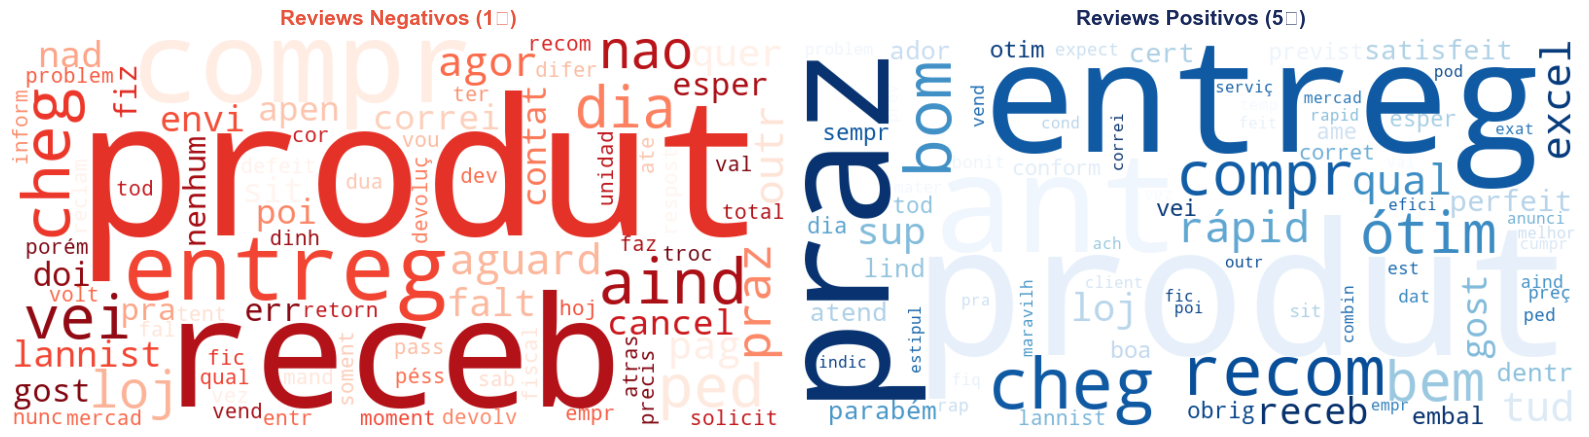

💡 Observe as diferenças: palavras como 'cheg', 'praz', 'recomend' dominam o 5★;
   já 'nao', 'produt', 'pag', 'entreg' aparecem mais no 1★.


In [34]:
# ── WordCloud: 1★ vs 5★ ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, nota, cor, titulo in [
    (axes[0], 1, '#E8553E', 'Reviews Negativos (1★)'),
    (axes[1], 5, '#1B2B5E', 'Reviews Positivos (5★)'),
]:
    textos = ' '.join(df_clean[df_clean['review_score']==nota]['texto_proc'])
    wc = WordCloud(width=800, height=400, background_color='white',
                   colormap='Reds' if nota==1 else 'Blues',
                   max_words=80, collocations=False).generate(textos)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(titulo, fontsize=15, fontweight='bold', color=cor, pad=10)

plt.tight_layout()
plt.savefig('02_wordcloud_bow.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 Observe as diferenças: palavras como 'cheg', 'praz', 'recomend' dominam o 5★;")
print("   já 'nao', 'produt', 'pag', 'entreg' aparecem mais no 1★.")

In [35]:
#Correção gramatical
#Carregar Corretor
from autocorrect import Speller
spell = Speller(lang='pt')

In [36]:
#Testando o corretor
print(spell('otimo'))
print(spell(('Otimo menssagem entnedi cehgando CEHGANDO outurbo voo')))
#CUIDADO corretor não funciona bem com palavras em MAIÚSCULO 

ótimo
Ótimo mensagem entendi chegando CEHGANDO outubro voo


---
## Aplicação Pratica 3 — TF-IDF

> **Objetivo:** calcular pesos TF-IDF, comparar com BoW e identificar os tokens mais discriminativos de cada nota.

In [37]:
# a) Matriz TF-IDF
vectorizer_tfidf = TfidfVectorizer(max_features=5000, min_df=3,
                                    ngram_range=(1,1), sublinear_tf=True)
X_tfidf = vectorizer_tfidf.fit_transform(df_clean['texto_proc'])
vocab_tfidf = vectorizer_tfidf.get_feature_names_out()
print(f"Shape TF-IDF: {X_tfidf.shape}")

# b) Comparação para 'entrega'
# Encontra índice do stemma de 'entrega'
stem_entrega = stemmer.stem('entrega')
print(f"\nStemma de 'entrega': '{stem_entrega}'")

if stem_entrega in vocab_tfidf:
    idx_t = list(vocab_tfidf).index(stem_entrega)
    idx_b = list(vocab).index(stem_entrega) if stem_entrega in vocab else None
    media_tfidf = X_tfidf[:, idx_t].toarray().mean()
    if idx_b is not None:
        media_bow = X_bow[:, idx_b].toarray().mean()
        print(f"  BoW médio   de '{stem_entrega}': {media_bow:.4f}")
    print(f"  TF-IDF médio de '{stem_entrega}': {media_tfidf:.4f}")
    print(f"  IDF do token : {vectorizer_tfidf.idf_[idx_t]:.4f}  (baixo = muito frequente no corpus)")

# c) Top tokens por TF-IDF médio por nota
import scipy.sparse as sp
notas_analise = [1, 5]
print()
for nota in notas_analise:
    mask = df_clean['review_score'].values == nota
    X_nota = X_tfidf[mask]
    medias = np.asarray(X_nota.mean(axis=0)).flatten()
    top_idx = medias.argsort()[::-1][:10]
    print(f"Top 10 tokens por TF-IDF médio — {nota}★:")
    for rank, idx in enumerate(top_idx, 1):
        print(f"  {rank:2}. {vocab_tfidf[idx]:<20} {medias[idx]:.5f}")
    print()

Shape TF-IDF: (41352, 3001)

Stemma de 'entrega': 'entreg'
  BoW médio   de 'entreg': 0.2981
  TF-IDF médio de 'entreg': 0.0629
  IDF do token : 2.2958  (baixo = muito frequente no corpus)

Top 10 tokens por TF-IDF médio — 1★:
   1. receb                0.08721
   2. produt               0.08667
   3. entreg               0.05392
   4. compr                0.05366
   5. aind                 0.04394
   6. cheg                 0.02953
   7. nao                  0.02906
   8. ped                  0.02840
   9. vei                  0.02660
  10. dia                  0.02500

Top 10 tokens por TF-IDF médio — 5★:
   1. produt               0.08286
   2. praz                 0.07901
   3. bom                  0.07567
   4. entreg               0.07153
   5. ant                  0.07001
   6. recom                0.06481
   7. ótim                 0.05634
   8. cheg                 0.04932
   9. excel                0.04237
  10. rápid                0.04153



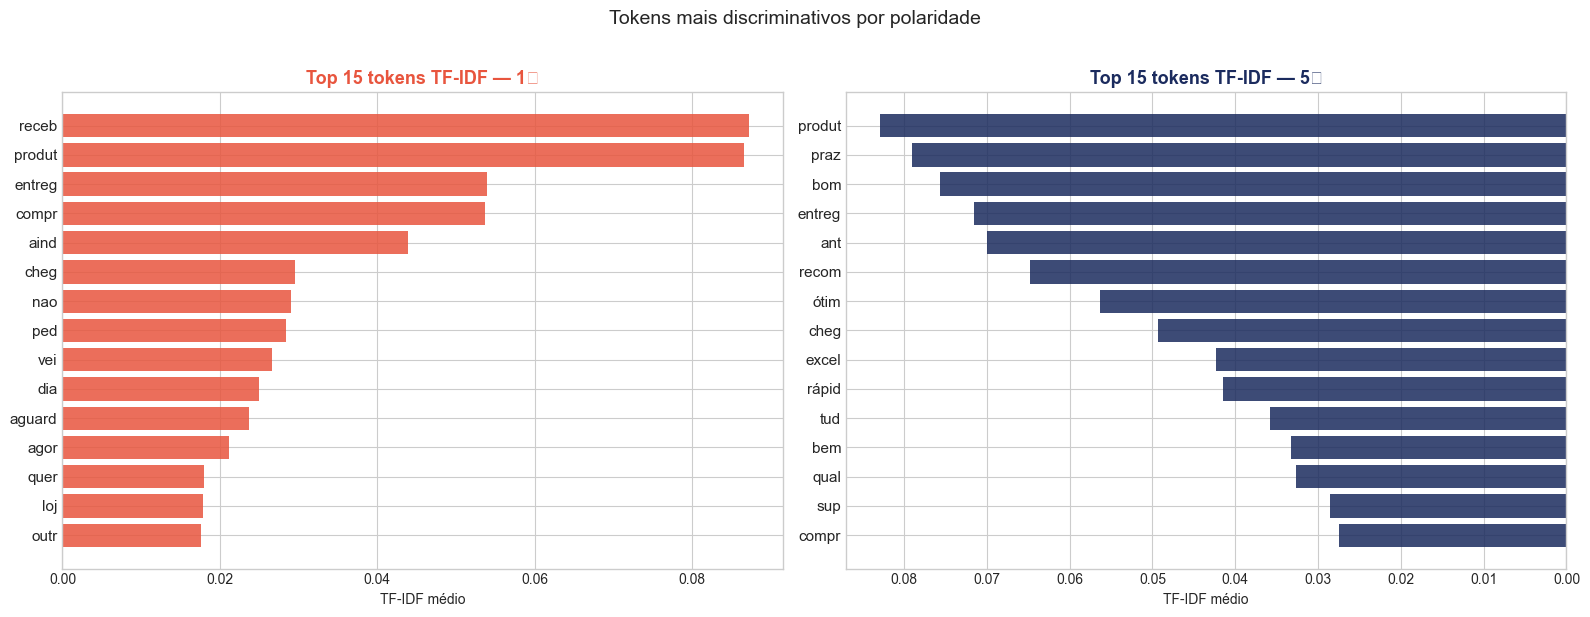

In [38]:
# ── Visualização: Top TF-IDF por nota ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, nota, cor in [(axes[0], 1, '#E8553E'), (axes[1], 5, '#1B2B5E')]:
    mask = df_clean['review_score'].values == nota
    medias = np.asarray(X_tfidf[mask].mean(axis=0)).flatten()
    top_idx = medias.argsort()[::-1][:15]
    tokens = [vocab_tfidf[i] for i in top_idx]
    pesos = [medias[i] for i in top_idx]

    bars = ax.barh(range(len(tokens)), pesos[::-1], color=cor, alpha=0.85)
    ax.set_yticks(range(len(tokens)))
    ax.set_yticklabels(tokens[::-1], fontsize=11)
    ax.set_title(f'Top 15 tokens TF-IDF — {nota}★', fontsize=13, fontweight='bold', color=cor)
    ax.set_xlabel('TF-IDF médio')
    ax.invert_xaxis() if nota==5 else None

plt.suptitle('Tokens mais discriminativos por polaridade', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('03_tfidf_por_nota.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Aplicação Pratica 4 — Classificador Baseline

> **Objetivo:** treinar um classificador de sentimento simples usando TF-IDF como features, e avaliar sua performance.
> 
> Vamos simplificar para **classificação binária**: negativo (1–2★) vs positivo (4–5★), ignorando o neutro (3★).

In [39]:

# a) Rótulo binário
df_bin = df_clean[df_clean['review_score'] != 3].copy()
df_bin['sentimento'] = df_bin['review_score'].apply(
    lambda s: 'positivo' if s >= 4 else 'negativo'
)
print(f"Dataset binário: {len(df_bin):,} reviews")
print(df_bin['sentimento'].value_counts().to_string())

# b) Vetorização + split
vec_bin = TfidfVectorizer(max_features=8000, min_df=3, sublinear_tf=True)
X = vec_bin.fit_transform(df_bin['texto_proc'])
y = df_bin['sentimento']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"\nTreino: {X_train.shape[0]:,} | Teste: {X_test.shape[0]:,}")

# c) Treino
clf = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
clf.fit(X_train, y_train)
print("\n✅ Modelo treinado!")

Dataset binário: 37,720 reviews
sentimento
positivo    26334
negativo    11386

Treino: 30,176 | Teste: 7,544

✅ Modelo treinado!


Accuracy: 91.98%

Classification Report:
              precision    recall  f1-score   support

    negativo      0.864     0.871     0.868      2277
    positivo      0.944     0.941     0.942      5267

    accuracy                          0.920      7544
   macro avg      0.904     0.906     0.905      7544
weighted avg      0.920     0.920     0.920      7544



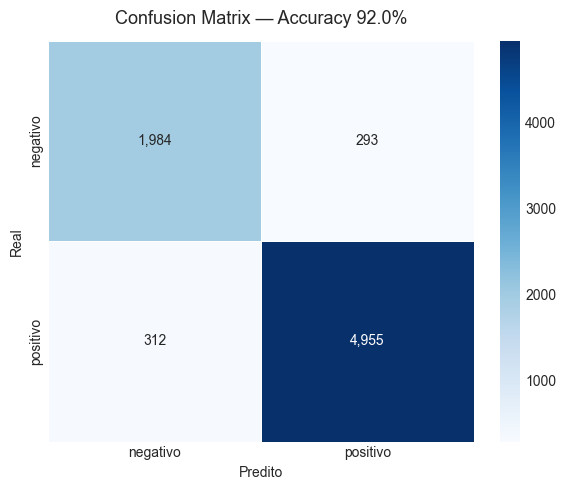

In [40]:
# d) Avaliação
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc*100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, digits=3))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=['negativo','positivo'])
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=ax,
            xticklabels=['negativo','positivo'],
            yticklabels=['negativo','positivo'],
            linewidths=0.5)
ax.set_title(f'Confusion Matrix — Accuracy {acc*100:.1f}%', fontsize=13, pad=12)
ax.set_ylabel('Real')
ax.set_xlabel('Predito')
plt.tight_layout()
plt.savefig('04_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# e) DESAFIO — Tokens mais discriminativos
vocab_bin = vec_bin.get_feature_names_out()
coefs = clf.coef_[0]  # coeficiente para classe 'positivo' (sigmoide)

top_positivo = coefs.argsort()[::-1][:15]
top_negativo = coefs.argsort()[:15]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, indices, cor, titulo in [
    (axes[0], top_negativo, '#E8553E', 'Tokens → NEGATIVO'),
    (axes[1], top_positivo, '#1B2B5E', 'Tokens → POSITIVO'),
]:
    tokens = [vocab_bin[i] for i in indices]
    pesos = [abs(coefs[i]) for i in indices]
    ax.barh(range(len(tokens)), pesos[::-1], color=cor, alpha=0.85)
    ax.set_yticks(range(len(tokens)))
    ax.set_yticklabels(tokens[::-1], fontsize=11)
    ax.set_title(titulo, fontsize=13, fontweight='bold', color=cor)
    ax.set_xlabel('|Coeficiente| da Regressão Logística')

plt.suptitle('Palavras com maior impacto na classificação de sentimento', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('05_coeficientes_modelo.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 Discussão:")
print("  • Esses coeficientes são interpretáveis — diferente do que veremos com embeddings no Módulo 2")
print("  • Tokens de negação ('nao') aparecem porque o stemming não captura contexto")
print("  • No Módulo 3 veremos como LLMs entendem negação contextualmente")

---
## Resumo e Discussão

| Métrica | Valor |
|---|---|
| Reviews com texto | ~41.728 |
| Accuracy (TF-IDF + LR) | ~91-93% |
| Esparsidade da matriz BoW | ~99% |
| Vocabulário (max_features) | 5.000-8.000 tokens |

### O que aprendemos:
1. **BoW** é simples e eficiente, mas ignora ordem e semântica
2. **TF-IDF** melhora a discriminação penalizando termos comuns
3. Um **classificador linear** sobre TF-IDF já atinge boa performance em sentiment analysis
4. Os **coeficientes são interpretáveis** — ponto forte para negócio



In [ ]:
# ── Análise de erros — revisão qualitativa ──────────────────
df_test = df_bin.iloc[y_test.index - df_bin.index[0] if hasattr(y_test.index,'_start') else slice(None)]

# Forma alternativa compatível
idx_test = y_test.index
df_erros = df_bin.loc[idx_test].copy()
df_erros['pred'] = y_pred
df_erros['acertou'] = df_erros['sentimento'] == df_erros['pred']

erros = df_erros[~df_erros['acertou']]
print(f"Total de erros no teste: {len(erros):,} ({len(erros)/len(df_erros)*100:.1f}%)")
print("\nExemplos de erros de classificação:")
sample_erros = erros.sample(min(5, len(erros)), random_state=42)
for _, row in sample_erros.iterrows():
    print(f"  Score: {row['review_score']}★ | Real: {row['sentimento']} | Predito: {row['pred']}")
    print(f"  Texto: {str(row['review_comment_message'])[:120]}")
    print()